## Блок 1.1: Импорты библиотек

Подключаем стек:
- **pandas, numpy, matplotlib, seaborn** — стандартный набор
- **catboost** — для финальной модели
- **sklearn.model_selection.TimeSeriesSplit** — для кросс-валидации по времени
- **sklearn.metrics** — все стандартные метрики бинарной классификации
- **shap** — библиотека для интерпретации ML-моделей

`shap` — единственная новая библиотека по сравнению с предыдущими ноутбуками.
Она реализует алгоритм **SHapley Additive exPlanations**, основанный на
теории кооперативных игр (Шепли, 1953). Идея: для каждого предсказания
рассчитать **вклад каждого признака**.

Из `src/features_final.py` импортируем обновлённый список признаков,
включая `TEXT_FEATURES = ['tender_name']`.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from catboost import CatBoostClassifier, Pool
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import (
roc_auc_score, f1_score, precision_score, recall_score, accuracy_score, confusion_matrix
)
import sys
import warnings

warnings.filterwarnings('ignore')
sys.path.insert(0,'..')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

from src.features_final import FEATURE_COLS, CAT_FEATURES, TEXT_FEATURES, TARGET

print("Все реди")
print(f"Признаков всего: {len(FEATURE_COLS)}")

Все реди
Признаков всего: 28


In [4]:
# Используем v3 (с признаками cross-history) + добавляем текст
df = pd.read_parquet('../data/processed/tender_data_v3.parquet')

if 'tender_name' not in df.columns:
    df_raw = pd.read_csv('../data/raw/tender_data.csv')
    df_raw = df_raw.sort_values('publication_date').reset_index(drop=True)
    df['tender_name'] = df_raw['tender_name'].fillna('').astype(str).values

# Заполняем пропуски
df['cust_proc_success_rate'] = df['cust_proc_success_rate'].fillna(0.5)
df['cust_proc_count'] = df['cust_proc_count'].fillna(0)

# Сортировка обязательна
df = df.sort_values('publication_date').reset_index(drop=True)

print(f"Размер: {df.shape}")
print(f"Период: {df['publication_date'].min()} — {df['publication_date'].max()}")
print(f"Баланс target: {df[TARGET].mean():.3f}")

Размер: (4519, 31)
Период: 2017-11-22 11:56:21 — 2023-04-24 11:24:08
Баланс target: 0.352


## Блок 2.1: Настройка кросс-валидации по времени

`TimeSeriesSplit(n_splits=5)` — это специальный валидатор для временных
рядов. В отличие от обычной k-fold кросс-валидации, он **не перемешивает**
данные:

- **Fold 1:** train — первые ~17%, test — следующие ~17%
- **Fold 2:** train — первые ~33%, test — следующие ~17%
- **Fold 3:** train — первые ~50%, test — следующие ~17%
- **Fold 4:** train — первые ~67%, test — следующие ~17%
- **Fold 5:** train — первые ~83%, test — следующие ~17%

**Почему именно так:**
- В реальном применении модель будет предсказывать **будущие** тендеры
  на основе **прошлых**.
- Случайная k-fold кросс-валидация позволяет модели «видеть» будущее
  при обучении (нерелистичный сценарий).
- TimeSeriesSplit имитирует production-условия: каждый раз модель
  обучается на прошлом и тестируется на будущем.

`MODEL_PARAMS` — словарь с параметрами финальной модели из эксперимента 5.
Один источник правды — менять параметры нужно только здесь.

In [5]:
# 5 фолдов, каждый последующий обучается на больших данных
N_SPLITS = 5
tscv = TimeSeriesSplit(n_splits=N_SPLITS)

X = df[FEATURE_COLS]
y = df[TARGET]

# Параметры финальной модели (из эксперимента 5)
MODEL_PARAMS = {
    'iterations': 2000,
    'learning_rate': 0.02,
    'depth': 6,
    'eval_metric': 'AUC',
    'random_seed': 42,
    'early_stopping_rounds': 100,
    'auto_class_weights': 'Balanced',
    'verbose': 0,
}

# Для хранения результатов
fold_results = []

print(f"Будет {N_SPLITS} фолдов")
print(f"Размер выборки: {len(df):,}")

Будет 5 фолдов
Размер выборки: 4,519


## Блок 2.2: Запуск кросс-валидации

Цикл по 5 фолдам с одинаковой логикой:

1. Разделяем X и y на train/test для текущего фолда
2. Создаём CatBoost Pool с категориальными и текстовыми признаками
3. Обучаем модель с теми же параметрами, что и финальная
4. Считаем все метрики (через нашу функцию `evaluate_model`)
5. Сохраняем результат + временные диапазоны фолдов

**Что важно записать для каждого фолда:**
- Размер train и test
- Период по датам (для интерпретации)
- AUC, F1, Precision, Recall
- Best iteration

Временные периоды важны: если в каком-то фолде AUC резко падает,
по датам можно понять, **что именно произошло** в данных в этот период
(экономический шок, изменение поведения заказчиков и т.д.).

In [6]:
print("="*70)
print("КРОСС-ВАЛИДАЦИЯ ПО ВРЕМЕНИ")
print("="*70)

for fold_idx, (train_idx, test_idx) in enumerate(tscv.split(X), 1):
    X_tr, X_te = X.iloc[train_idx], X.iloc[test_idx]
    y_tr, y_te = y.iloc[train_idx], y.iloc[test_idx]

    # Определяем временной диапазон фолда
    train_dates = df.iloc[train_idx]['publication_date']
    test_dates = df.iloc[test_idx]['publication_date']

    # Создаём pool с текстовыми и категориальными признаками
    train_pool = Pool(X_tr, y_tr, cat_features=CAT_FEATURES, text_features=TEXT_FEATURES)
    test_pool = Pool(X_te, y_te, cat_features=CAT_FEATURES, text_features=TEXT_FEATURES)

    # Обучаем
    model = CatBoostClassifier(**MODEL_PARAMS)
    model.fit(train_pool, eval_set=test_pool, use_best_model=True)

    # Предсказываем
    y_pred = model.predict(X_te)
    y_pred_proba = model.predict_proba(X_te)[:, 1]

    # Метрики
    fold_metrics = {
        'fold': fold_idx,
        'train_size': len(train_idx),
        'test_size': len(test_idx),
        'train_period': f"{train_dates.min().date()} → {train_dates.max().date()}",
        'test_period': f"{test_dates.min().date()} → {test_dates.max().date()}",
        'auc': roc_auc_score(y_te, y_pred_proba),
        'f1': f1_score(y_te, y_pred),
        'precision': precision_score(y_te, y_pred),
        'recall': recall_score(y_te, y_pred),
        'accuracy': accuracy_score(y_te, y_pred),
        'best_iter': model.get_best_iteration(),
    }
    fold_results.append(fold_metrics)

    print(f"\nFold {fold_idx}:")
    print(f"  Train: {len(train_idx):,} ({fold_metrics['train_period']})")
    print(f"  Test:  {len(test_idx):,} ({fold_metrics['test_period']})")
    print(f"  AUC: {fold_metrics['auc']:.4f}, F1: {fold_metrics['f1']:.4f}, Recall: {fold_metrics['recall']:.4f}")

КРОСС-ВАЛИДАЦИЯ ПО ВРЕМЕНИ

Fold 1:
  Train: 754 (2017-11-22 → 2020-08-03)
  Test:  753 (2020-08-03 → 2021-06-01)
  AUC: 0.7460, F1: 0.6159, Recall: 0.6028

Fold 2:
  Train: 1,507 (2017-11-22 → 2021-06-01)
  Test:  753 (2021-06-02 → 2022-02-11)
  AUC: 0.7821, F1: 0.6610, Recall: 0.8275

Fold 3:
  Train: 2,260 (2017-11-22 → 2022-02-11)
  Test:  753 (2022-02-11 → 2022-07-08)
  AUC: 0.7370, F1: 0.5974, Recall: 0.7480

Fold 4:
  Train: 3,013 (2017-11-22 → 2022-07-08)
  Test:  753 (2022-07-08 → 2022-11-03)
  AUC: 0.6633, F1: 0.5588, Recall: 0.6020

Fold 5:
  Train: 3,766 (2017-11-22 → 2022-11-03)
  Test:  753 (2022-11-03 → 2023-04-24)
  AUC: 0.7108, F1: 0.6055, Recall: 0.6326


In [7]:
cv_df = pd.DataFrame(fold_results)

print("\n" + "="*70)
print("СВОДКА ПО ФОЛДАМ")
print("="*70)
print(cv_df[['fold', 'auc', 'f1', 'precision', 'recall', 'accuracy', 'best_iter']].round(4).to_string(index=False))

print("\n" + "="*70)
print("СТАТИСТИКА ПО МЕТРИКАМ")
print("="*70)

stats = cv_df[['auc', 'f1', 'precision', 'recall', 'accuracy']].agg(['mean', 'std', 'min', 'max']).round(4)
print(stats)

# Главный вывод
print("\n" + "="*70)
print("ИТОГ КРОСС-ВАЛИДАЦИИ")
print("="*70)
print(f"AUC = {cv_df['auc'].mean():.4f} ± {cv_df['auc'].std():.4f}")
print(f"F1  = {cv_df['f1'].mean():.4f} ± {cv_df['f1'].std():.4f}")


СВОДКА ПО ФОЛДАМ
 fold    auc     f1  precision  recall  accuracy  best_iter
    1 0.7460 0.6159     0.6296  0.6028    0.7185          8
    2 0.7821 0.6610     0.5504  0.8275    0.6799        110
    3 0.7370 0.5974     0.4973  0.7480    0.6707         10
    4 0.6633 0.5588     0.5214  0.6020    0.6162          9
    5 0.7108 0.6055     0.5806  0.6326    0.6574         20

СТАТИСТИКА ПО МЕТРИКАМ
         auc      f1  precision  recall  accuracy
mean  0.7278  0.6077     0.5559  0.6826    0.6685
std   0.0442  0.0368     0.0517  0.1008    0.0370
min   0.6633  0.5588     0.4973  0.6020    0.6162
max   0.7821  0.6610     0.6296  0.8275    0.7185

ИТОГ КРОСС-ВАЛИДАЦИИ
AUC = 0.7278 ± 0.0442
F1  = 0.6077 ± 0.0368


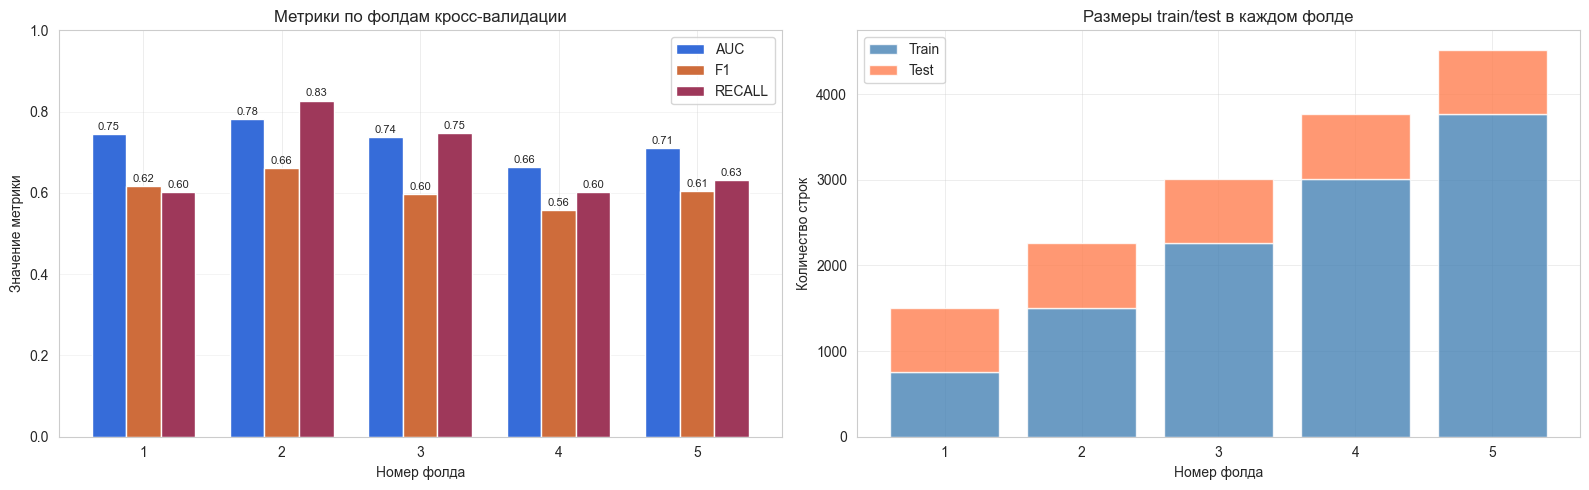

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# График 1: AUC и F1 по фолдам
metrics_to_plot = ['auc', 'f1', 'recall']
x = cv_df['fold'].values
width = 0.25

for i, metric in enumerate(metrics_to_plot):
    axes[0].bar(x + i*width - width, cv_df[metric], width, label=metric.upper())

axes[0].set_xticks(x)
axes[0].set_xlabel('Номер фолда')
axes[0].set_ylabel('Значение метрики')
axes[0].set_title('Метрики по фолдам кросс-валидации')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)
axes[0].set_ylim(0, 1)

# Подписи
for i, metric in enumerate(metrics_to_plot):
    for fold, val in zip(cv_df['fold'], cv_df[metric]):
        axes[0].text(fold + i*width - width, val + 0.01, f'{val:.2f}',
                     ha='center', fontsize=8)

# График 2: размеры фолдов
axes[1].bar(cv_df['fold'], cv_df['train_size'], label='Train', color='steelblue', alpha=0.8)
axes[1].bar(cv_df['fold'], cv_df['test_size'], bottom=cv_df['train_size'],
            label='Test', color='coral', alpha=0.8)
axes[1].set_xlabel('Номер фолда')
axes[1].set_ylabel('Количество строк')
axes[1].set_title('Размеры train/test в каждом фолде')
axes[1].legend()

plt.tight_layout()
plt.savefig('../reports/cv_folds_metrics.png', dpi=150, bbox_inches='tight')
plt.show()

In [9]:
cv_df.to_csv('../reports/cv_results.csv', index=False)
print("Сохранено: reports/cv_results.csv")

Сохранено: reports/cv_results.csv


## Блок 3.1: Подготовка финальной модели для SHAP-анализа

Обучаем финальную модель на полном train set (как в ноутбуке 05) для
последующего SHAP-анализа.

**Почему отдельно от CV:** в кросс-валидации мы получили 5 разных моделей.
Для интерпретации нам нужна **одна** модель, которая будет использоваться
в production (Streamlit-приложении).

Это та же модель, что сохранена в `models/catboost_final.cbm`.

In [10]:
import shap

# Финальная модель — обучаем на всём train (без CV-фолдов)
train_mask = df['is_train']
X_train = df[train_mask][FEATURE_COLS]
y_train = df[train_mask][TARGET]
X_test = df[~train_mask][FEATURE_COLS]
y_test = df[~train_mask][TARGET]

train_pool_full = Pool(X_train, y_train, cat_features=CAT_FEATURES, text_features=TEXT_FEATURES)
test_pool_full = Pool(X_test, y_test, cat_features=CAT_FEATURES, text_features=TEXT_FEATURES)

# Обучаем финальную модель
model_final = CatBoostClassifier(**MODEL_PARAMS)
model_final.fit(train_pool_full, eval_set=test_pool_full, use_best_model=True)

print(f"Финальная модель обучена. Best iter: {model_final.get_best_iteration()}")
print(f"AUC на тесте: {roc_auc_score(y_test, model_final.predict_proba(X_test)[:, 1]):.4f}")

Финальная модель обучена. Best iter: 538
AUC на тесте: 0.7125


## Блок 3.2: Расчёт SHAP-значений

CatBoost имеет **встроенный** расчёт SHAP-значений через
`get_feature_importance(type='ShapValues')`. Это в разы быстрее, чем
универсальный `shap.TreeExplainer`.

**Что возвращает функция:**
- Матрицу размера `[N_строк × (N_признаков + 1)]`
- Последняя колонка — `bias` (базовое предсказание модели)
- Остальные колонки — вклад каждого признака в предсказание для каждой строки

**Как читать SHAP-значения:**
- Положительное значение → признак **повысил** вероятность предсказания «1»
- Отрицательное → признак **понизил**
- |Значение| показывает силу влияния

Сумма всех SHAP-значений + bias = логит финального предсказания. Это
**аддитивная декомпозиция**: предсказание = вклад₁ + вклад₂ + ... + bias.

In [11]:
# CatBoost умеет сам считать SHAP-значения нативно — это быстрее, чем shap.TreeExplainer
shap_values = model_final.get_feature_importance(
    test_pool_full,
    type='ShapValues'
)

# Последняя колонка — bias (базовая вероятность), её отделяем
bias = shap_values[:, -1]
shap_values_only = shap_values[:, :-1]

print(f"Размер SHAP-матрицы: {shap_values_only.shape}")
print(f"Bias (средняя базовая вероятность): {bias.mean():.4f}")
print(f"Признаки: {len(FEATURE_COLS)}")

Размер SHAP-матрицы: (904, 28)
Bias (средняя базовая вероятность): -0.1721
Признаки: 28


Топ-15 признаков по SHAP-важности:
               feature  shap_importance
cust_proc_success_rate         0.365922
           tender_name         0.311195
procedure_success_rate         0.146047
 customer_success_rate         0.122605
  region_total_tenders         0.099335
   region_success_rate         0.044610
       tender_security         0.036642
customer_total_tenders         0.032555
     price_vs_cust_avg         0.029039
       cust_proc_count         0.028709
                 month         0.028048
          day_of_month         0.025972
        security_ratio         0.025864
     advance_money_pct         0.025542
       customer_region         0.021973


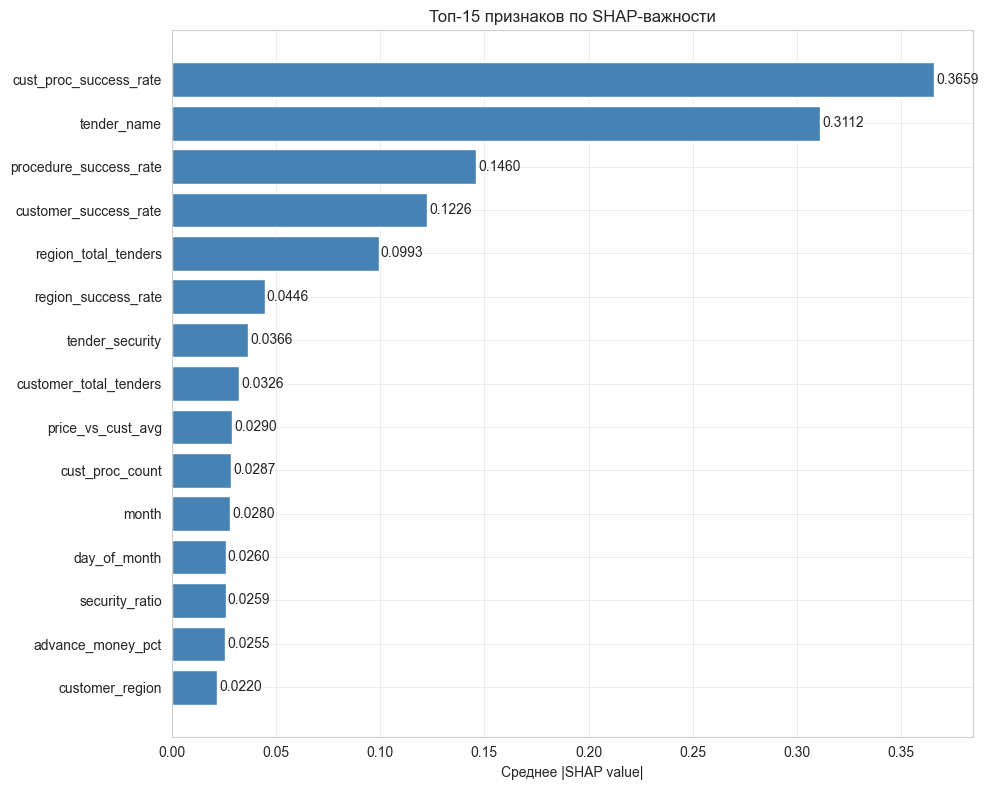

In [12]:
# Среднее абсолютное значение SHAP по каждому признаку
shap_importance = pd.DataFrame({
    'feature': FEATURE_COLS,
    'shap_importance': np.abs(shap_values_only).mean(axis=0)
}).sort_values('shap_importance', ascending=False)

print("Топ-15 признаков по SHAP-важности:")
print(shap_importance.head(15).to_string(index=False))

# Визуализация
fig, ax = plt.subplots(figsize=(10, 8))
top15 = shap_importance.head(15).iloc[::-1]
ax.barh(top15['feature'], top15['shap_importance'], color='steelblue')
ax.set_xlabel('Среднее |SHAP value|')
ax.set_title('Топ-15 признаков по SHAP-важности')

for i, v in enumerate(top15['shap_importance']):
    ax.text(v + 0.001, i, f'{v:.4f}', va='center', fontsize=10)

plt.tight_layout()
plt.savefig('../reports/shap_global_importance.png', dpi=150, bbox_inches='tight')
plt.show()

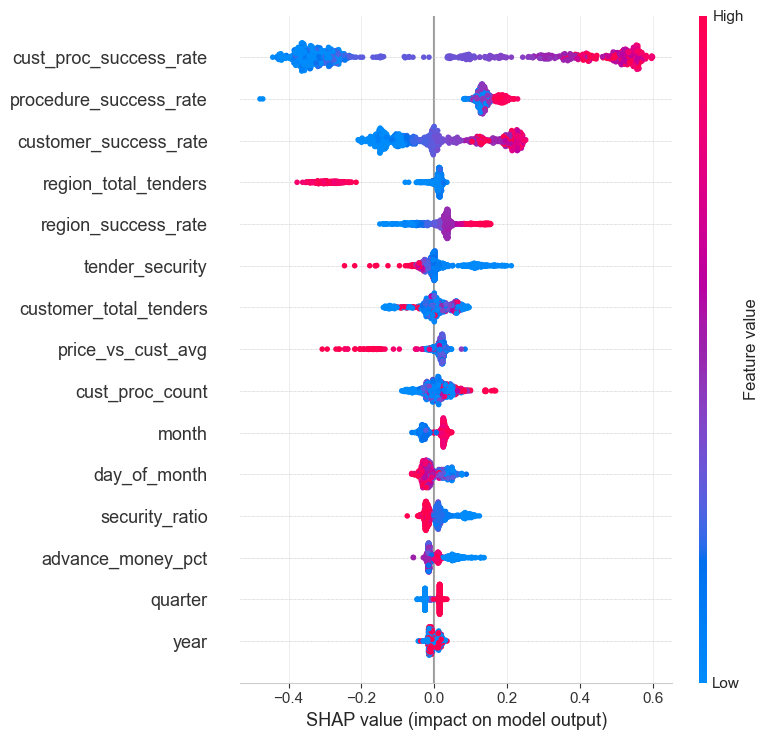

In [13]:
# график SHAP
# Каждая точка — один тендер, цвет — значение признака, x — вклад в предсказание

# Подготовка: SHAP плохо работает с текстовыми и категориальными в test_pool
# Используем только числовые для summary plot
numeric_features = [f for f in FEATURE_COLS if f not in CAT_FEATURES and f not in TEXT_FEATURES]
numeric_indices = [FEATURE_COLS.index(f) for f in numeric_features]

shap_numeric = shap_values_only[:, numeric_indices]
X_test_numeric = X_test[numeric_features]

shap.summary_plot(
    shap_numeric,
    X_test_numeric,
    feature_names=numeric_features,
    show=False,
    max_display=15
)
plt.savefig('../reports/shap_summary_plot.png', dpi=150, bbox_inches='tight')
plt.show()

In [14]:
# Берём 3 примера из теста: успешный, неуспешный, "пограничный"
y_pred_proba = model_final.predict_proba(X_test)[:, 1]

# Самый "успешный" по модели
top_success_idx = np.argmax(y_pred_proba)
# Самый "неуспешный" по модели
top_fail_idx = np.argmin(y_pred_proba)
# Пограничный (около 0.5)
border_idx = np.argmin(np.abs(y_pred_proba - 0.5))

examples = {
    'Уверенный "состоится"': top_success_idx,
    'Уверенный "не состоится"': top_fail_idx,
    'Пограничный случай': border_idx,
}

for label, idx in examples.items():
    print("="*70)
    print(f"{label}")
    print("="*70)

    # Информация о тендере
    test_real_idx = X_test.index[idx]
    tender = df.loc[test_real_idx]
    print(f"Дата: {tender['publication_date'].date()}")
    print(f"Регион: {tender['customer_region']}")
    print(f"Процедура: {tender['procedure']}")
    print(f"Цена: {tender['start_price']:,.0f} руб")
    print(f"Реальный итог: {'СОСТОЯЛСЯ' if tender[TARGET] == 1 else 'НЕ состоялся'}")
    print(f"Прогноз модели: {y_pred_proba[idx]:.3f}")

    # Топ-5 факторов, повлиявших на это предсказание
    contributions = pd.DataFrame({
        'feature': FEATURE_COLS,
        'value': X_test.iloc[idx].values,
        'shap_value': shap_values_only[idx],
    })
    contributions['abs_shap'] = contributions['shap_value'].abs()
    top5 = contributions.nlargest(5, 'abs_shap')

    print(f"\nТоп-5 влияющих признаков:")
    for _, row in top5.iterrows():
        direction = "↑ повышает" if row['shap_value'] > 0 else "↓ понижает"
        print(f"  {row['feature']:30s} = {str(row['value'])[:30]:30s} {direction} ({row['shap_value']:+.3f})")
    print()

Уверенный "состоится"
Дата: 2022-12-23
Регион: Москва
Процедура: Конкурс
Цена: 2,684,445,815 руб
Реальный итог: СОСТОЯЛСЯ
Прогноз модели: 0.946

Топ-5 влияющих признаков:
  tender_name                    = Оказание услуг по исполнению ф ↑ повышает (+1.903)
  cust_proc_success_rate         = 0.8181818181818182             ↑ повышает (+0.554)
  customer_success_rate          = 0.8181818181818182             ↑ повышает (+0.239)
  region_total_tenders           = 1227                           ↓ понижает (-0.234)
  procedure_success_rate         = 0.7916666666666666             ↑ повышает (+0.180)

Уверенный "не состоится"
Дата: 2023-02-10
Регион: Алтайский край
Процедура: Электронный аукцион
Цена: 506,411,999 руб
Реальный итог: НЕ состоялся
Прогноз модели: 0.142

Топ-5 влияющих признаков:
  tender_name                    = Выполнение подрядных работ по  ↓ понижает (-1.221)
  cust_proc_success_rate         = 0.1111111111111111             ↓ понижает (-0.353)
  customer_success_rate        

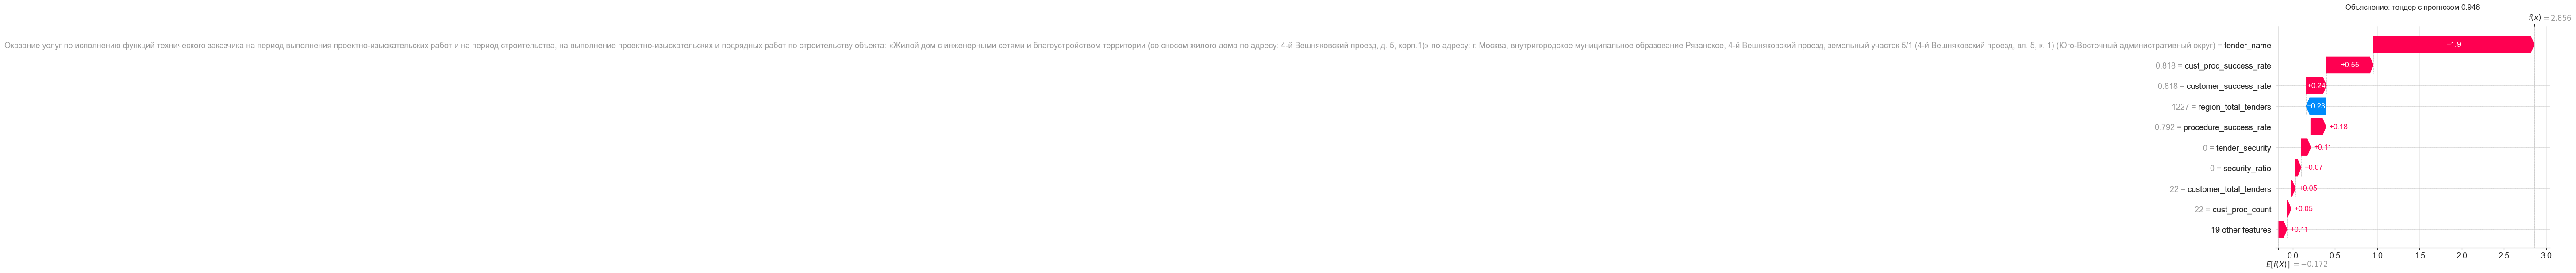

In [15]:
# Самый красивый и понятный график для защиты — waterfall
# Показывает пошагово, как формируется предсказание

example_idx = examples['Уверенный "состоится"']

# Создаём Explanation-объект
explanation = shap.Explanation(
    values=shap_values_only[example_idx],
    base_values=bias[example_idx],
    data=X_test.iloc[example_idx].values,
    feature_names=FEATURE_COLS
)

shap.waterfall_plot(explanation, max_display=10, show=False)
plt.title(f'Объяснение: тендер с прогнозом {y_pred_proba[example_idx]:.3f}')
plt.tight_layout()
plt.savefig('../reports/shap_waterfall_example.png', dpi=150, bbox_inches='tight')
plt.show()

In [16]:
# Создаём датафрейм с прогнозами и реальностью
analysis_df = X_test.copy()
analysis_df['y_true'] = y_test.values
analysis_df['y_pred_proba'] = y_pred_proba
analysis_df['y_pred'] = (y_pred_proba > 0.5).astype(int)
analysis_df['error'] = (analysis_df['y_true'] != analysis_df['y_pred']).astype(int)
analysis_df['error_type'] = 'OK'
analysis_df.loc[(analysis_df['y_true'] == 1) & (analysis_df['y_pred'] == 0), 'error_type'] = 'False Negative'
analysis_df.loc[(analysis_df['y_true'] == 0) & (analysis_df['y_pred'] == 1), 'error_type'] = 'False Positive'

# Восстанавливаем категориальные колонки для анализа
analysis_df['procedure'] = df.loc[X_test.index, 'procedure'].values
analysis_df['customer_region'] = df.loc[X_test.index, 'customer_region'].values
analysis_df['legislation'] = df.loc[X_test.index, 'legislation'].values

print("Распределение ошибок:")
print(analysis_df['error_type'].value_counts())
print(f"\nОбщая точность: {(analysis_df['error_type']=='OK').mean():.3f}")

Распределение ошибок:
error_type
OK                611
False Positive    170
False Negative    123
Name: count, dtype: int64

Общая точность: 0.676


Точность модели по типу процедуры:
                                                    total  errors  error_rate
procedure                                                                    
Открытый конкурс в электронной форме                  386     150       0.389
Электронный аукцион                                   253      62       0.245
Закупка иного способа размещения                      209      63       0.301
Конкурс в электронной форме                            23       7       0.304
Конкурс                                                21       7       0.333
Аукцион в электронной форме                             8       3       0.375
Запрос котировок в электронной форме                    3       1       0.333
Закупка у единственного поставщика (исполнителя...      1       0       0.000


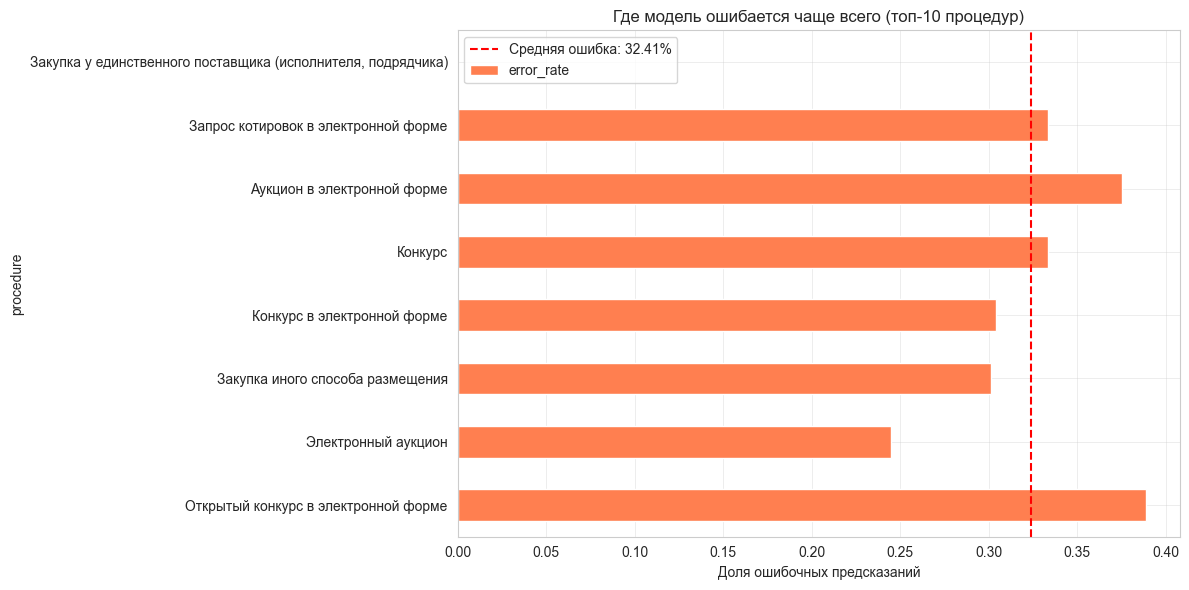

In [17]:
errors_by_procedure = analysis_df.groupby('procedure').agg(
    total=('error', 'size'),
    errors=('error', 'sum'),
    error_rate=('error', 'mean')
).sort_values('total', ascending=False).head(10)

print("Точность модели по типу процедуры:")
print(errors_by_procedure.round(3))

fig, ax = plt.subplots(figsize=(12, 6))
errors_by_procedure['error_rate'].plot(kind='barh', ax=ax, color='coral')
ax.set_xlabel('Доля ошибочных предсказаний')
ax.set_title('Где модель ошибается чаще всего (топ-10 процедур)')
ax.axvline(analysis_df['error'].mean(), color='red', linestyle='--',
           label=f'Средняя ошибка: {analysis_df["error"].mean():.2%}')
ax.legend()
plt.tight_layout()
plt.savefig('../reports/error_analysis_procedures.png', dpi=150, bbox_inches='tight')
plt.show()

In [18]:
analysis_df['price_bucket'] = pd.cut(
    analysis_df['start_price'],
    bins=[0, 1e7, 1e8, 1e9, 1e10, 1e12],
    labels=['<10 млн', '10-100 млн', '100 млн - 1 млрд', '1-10 млрд', '>10 млрд']
)

errors_by_price = analysis_df.groupby('price_bucket').agg(
    total=('error', 'size'),
    error_rate=('error', 'mean'),
    avg_pred=('y_pred_proba', 'mean'),
    actual_rate=('y_true', 'mean')
).round(3)

print("Точность модели по ценовым диапазонам:")
print(errors_by_price)

Точность модели по ценовым диапазонам:
                  total  error_rate  avg_pred  actual_rate
price_bucket                                              
<10 млн               0         NaN       NaN          NaN
10-100 млн            0         NaN       NaN          NaN
100 млн - 1 млрд    507       0.325     0.497        0.394
1-10 млрд           373       0.332     0.515        0.426
>10 млрд             24       0.167     0.465        0.375


In [19]:
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(y_test, y_pred_proba)
f1_scores = 2 * precision * recall / (precision + recall + 1e-10)

# Лучший порог по F1
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]
best_f1 = f1_scores[best_idx]

# Бизнес-ориентированный порог: высокий recall (чтобы не упустить тендеры)
# Найдём порог, при котором recall >= 0.75 и precision максимальный
recall_threshold = 0.75
high_recall_mask = recall[:-1] >= recall_threshold
if high_recall_mask.any():
    business_idx = np.where(high_recall_mask)[0][-1]  # последний с recall >= 0.75
    business_threshold = thresholds[business_idx]
    print(f"Бизнес-порог (recall ≥ {recall_threshold}):")
    print(f"  Порог: {business_threshold:.3f}")
    print(f"  Precision: {precision[business_idx]:.3f}")
    print(f"  Recall: {recall[business_idx]:.3f}")
    print(f"  F1: {f1_scores[business_idx]:.3f}")
else:
    business_threshold = best_threshold
    print(f"Порог recall ≥ 0.75 недостижим, используем оптимум F1")

print(f"\nОптимальный по F1:")
print(f"  Порог: {best_threshold:.3f}")
print(f"  F1: {best_f1:.3f}")
print(f"  Precision: {precision[best_idx]:.3f}")
print(f"  Recall: {recall[best_idx]:.3f}")

# Сохраняем константы
THRESHOLDS = {
    'default': 0.5,
    'optimal_f1': best_threshold,
    'business_recall_75': business_threshold if high_recall_mask.any() else best_threshold,
}
print(f"\nПороги для использования: {THRESHOLDS}")

Бизнес-порог (recall ≥ 0.75):
  Порог: 0.452
  Precision: 0.556
  Recall: 0.750
  F1: 0.639

Оптимальный по F1:
  Порог: 0.452
  F1: 0.639
  Precision: 0.556
  Recall: 0.750

Пороги для использования: {'default': 0.5, 'optimal_f1': np.float64(0.452025606784198), 'business_recall_75': np.float64(0.452025606784198)}


In [20]:
results_thresholds = []

for name, thr in THRESHOLDS.items():
    y_pred_thr = (y_pred_proba >= thr).astype(int)
    results_thresholds.append({
        'threshold_name': name,
        'threshold': thr,
        'accuracy': accuracy_score(y_test, y_pred_thr),
        'precision': precision_score(y_test, y_pred_thr),
        'recall': recall_score(y_test, y_pred_thr),
        'f1': f1_score(y_test, y_pred_thr),
    })

threshold_df = pd.DataFrame(results_thresholds).round(4)
print("Сравнение порогов классификации:")
print(threshold_df.to_string(index=False))
threshold_df.to_csv('../reports/thresholds_comparison.csv', index=False)

Сравнение порогов классификации:
    threshold_name  threshold  accuracy  precision  recall     f1
           default      0.500    0.6759     0.5904  0.6658 0.6258
        optimal_f1      0.452    0.6549     0.5565  0.7500 0.6389
business_recall_75      0.452    0.6549     0.5565  0.7500 0.6389


In [21]:
# Сохраняем модель (на случай если что-то изменилось)
model_final.save_model('../models/catboost_final.cbm')

# Сохраняем SHAP-значения для будущего использования
np.save('../models/shap_values_test.npy', shap_values)
np.save('../models/shap_bias.npy', bias)

# Сохраняем выбранный порог в src
with open('../src/thresholds.py', 'w', encoding='utf-8') as f:
    f.write('"""Пороги классификации для финальной модели."""\n\n')
    f.write(f'THRESHOLD_DEFAULT = 0.5\n')
    f.write(f'THRESHOLD_OPTIMAL_F1 = {best_threshold:.4f}\n')
    f.write(f'THRESHOLD_BUSINESS = {THRESHOLDS["business_recall_75"]:.4f}  # для рекомендаций\n')

print("✅ Все артефакты сохранены")

✅ Все артефакты сохранены


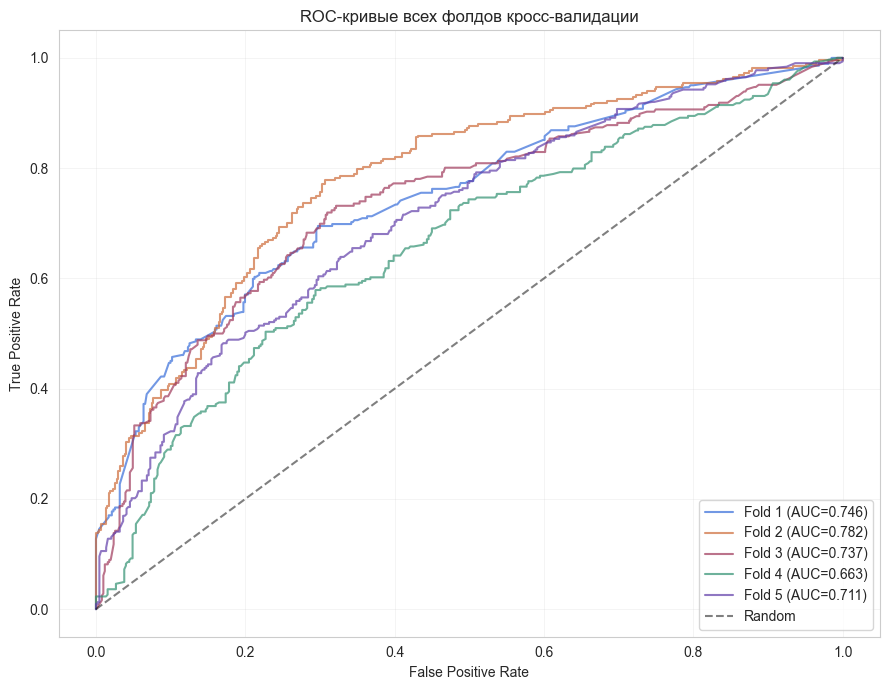

In [22]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve

fig, ax = plt.subplots(figsize=(9, 7))

# Перезапустим CV и сохраним все proba
all_proba = []
all_y_true = []

for fold_idx, (train_idx, test_idx) in enumerate(tscv.split(X), 1):
    X_tr, X_te = X.iloc[train_idx], X.iloc[test_idx]
    y_tr, y_te = y.iloc[train_idx], y.iloc[test_idx]

    train_pool = Pool(X_tr, y_tr, cat_features=CAT_FEATURES, text_features=TEXT_FEATURES)
    test_pool = Pool(X_te, y_te, cat_features=CAT_FEATURES, text_features=TEXT_FEATURES)

    model = CatBoostClassifier(**MODEL_PARAMS)
    model.fit(train_pool, eval_set=test_pool, use_best_model=True)

    y_proba = model.predict_proba(X_te)[:, 1]
    fpr, tpr, _ = roc_curve(y_te, y_proba)
    auc = roc_auc_score(y_te, y_proba)

    ax.plot(fpr, tpr, label=f'Fold {fold_idx} (AUC={auc:.3f})', alpha=0.7, linewidth=1.5)

ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC-кривые всех фолдов кросс-валидации')
ax.legend(loc='lower right')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../reports/cv_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

In [24]:
# Для каждого предсказания смотрим, насколько оно "далеко" от 0.5
analysis_df['confidence'] = np.abs(analysis_df['y_pred_proba'] - 0.5) * 2

# Группируем по уровню уверенности
analysis_df['confidence_level'] = pd.cut(
    analysis_df['confidence'],
    bins=[0, 0.3, 0.6, 1.0],
    labels=['Низкая', 'Средняя', 'Высокая']
)

confidence_quality = analysis_df.groupby('confidence_level').agg(
    count=('error', 'size'),
    accuracy=('error', lambda x: 1 - x.mean())
).round(3)

print("Точность модели по уровню уверенности:")
print(confidence_quality)

Точность модели по уровню уверенности:
                  count  accuracy
confidence_level                 
Низкая              447     0.631
Средняя             368     0.698
Высокая              89     0.809
